In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path="/content/drive/MyDrive/Student Data/"

In [ ]:
print(path)

/content/drive/MyDrive/Student Data/


In [6]:
df = pd.read_csv(path+'student_dataset.csv', engine='python', on_bad_lines='warn')

In [ ]:
df.isnull().sum()

,0
study_hours,0
attendance,0
sleep_hours,0
internet_usage,0
assignments_completed,0
previous_score,0
exam_score,0
placement_status,0


In [ ]:
df.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


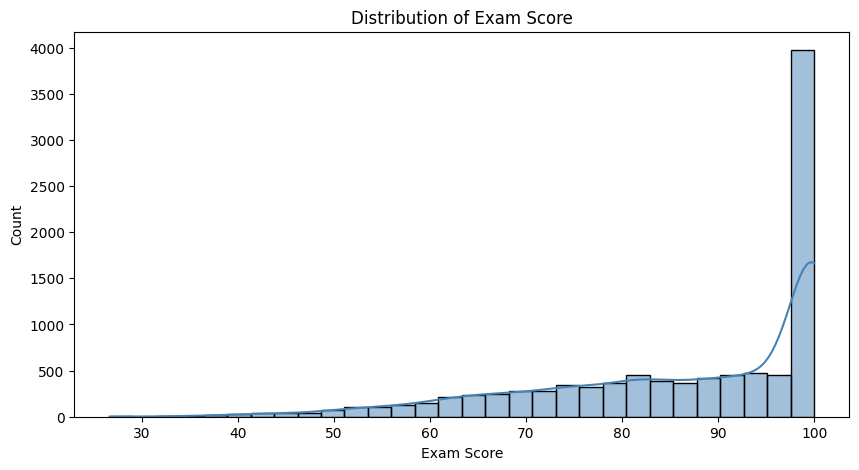

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df['exam_score'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Exam Score')
plt.xlabel('Exam Score')
plt.ylabel('Count')
plt.show()

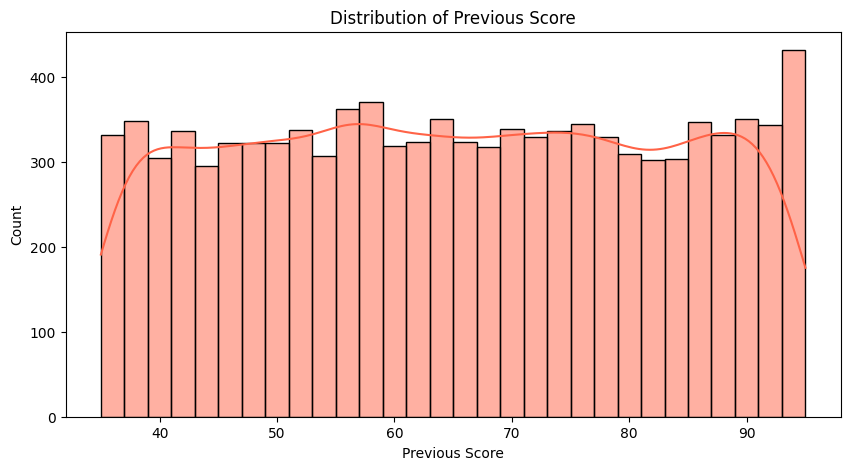

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['previous_score'], bins=30, kde=True, color='tomato')
plt.title('Distribution of Previous Score')
plt.xlabel('Previous Score')
plt.ylabel('Count')
plt.show()

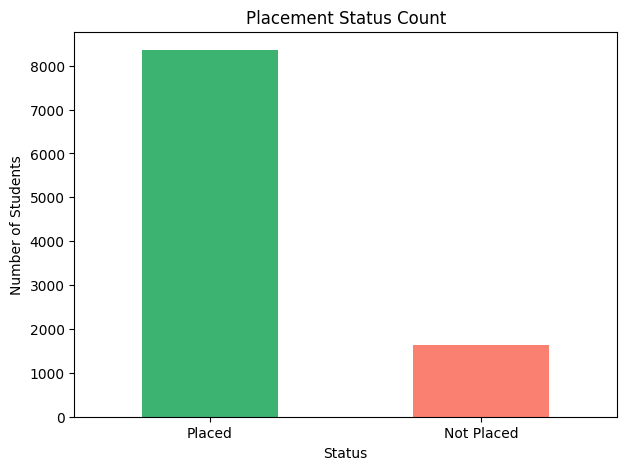

In [9]:
placement_counts = df['placement_status'].value_counts()

plt.figure(figsize=(7,5))
placement_counts.plot(kind='bar', color=['mediumseagreen', 'salmon'])
plt.title('Placement Status Count')
plt.xlabel('Status')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()

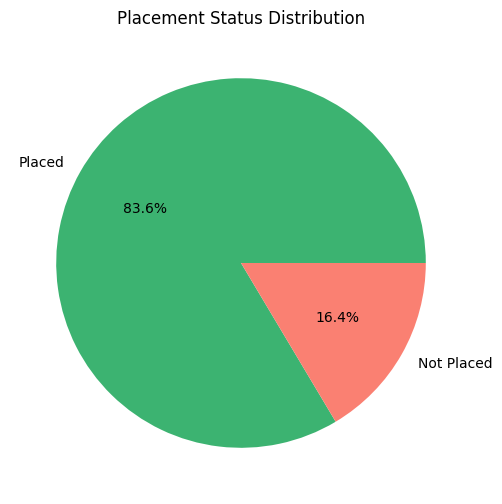

In [10]:
plt.figure(figsize=(6,6))
plt.pie(
    placement_counts,
    labels=placement_counts.index,
    autopct='%1.1f%%',
    colors=['mediumseagreen', 'salmon']
)
plt.title('Placement Status Distribution')
plt.show()

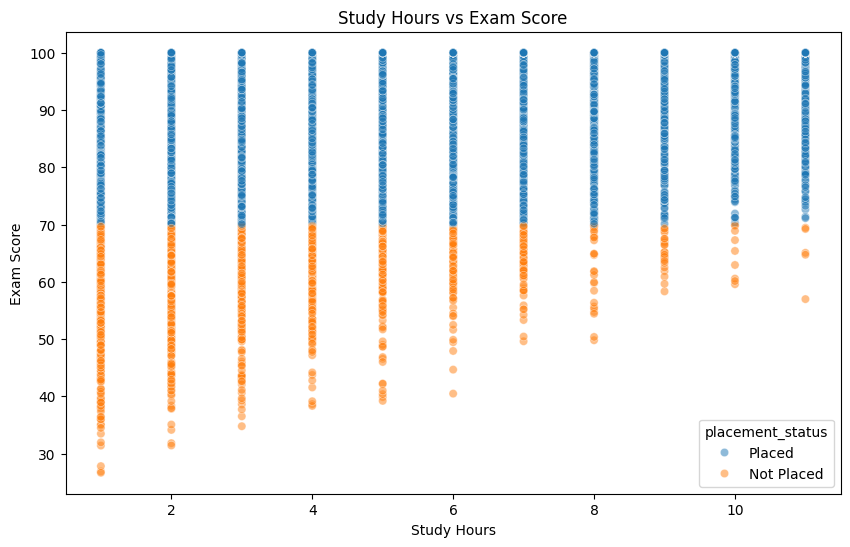

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='study_hours', y='exam_score', hue='placement_status', alpha=0.5)
plt.title('Study Hours vs Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.show()

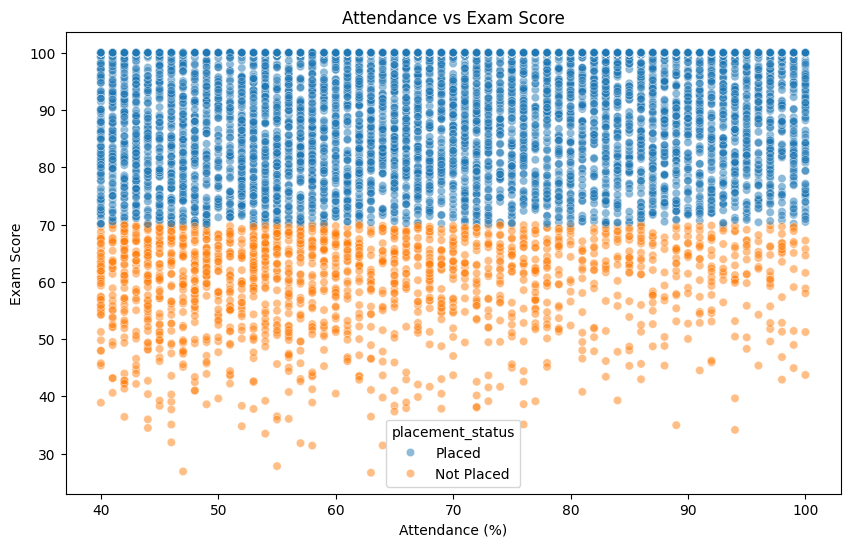

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='attendance', y='exam_score', hue='placement_status', alpha=0.5)
plt.title('Attendance vs Exam Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')
plt.show()

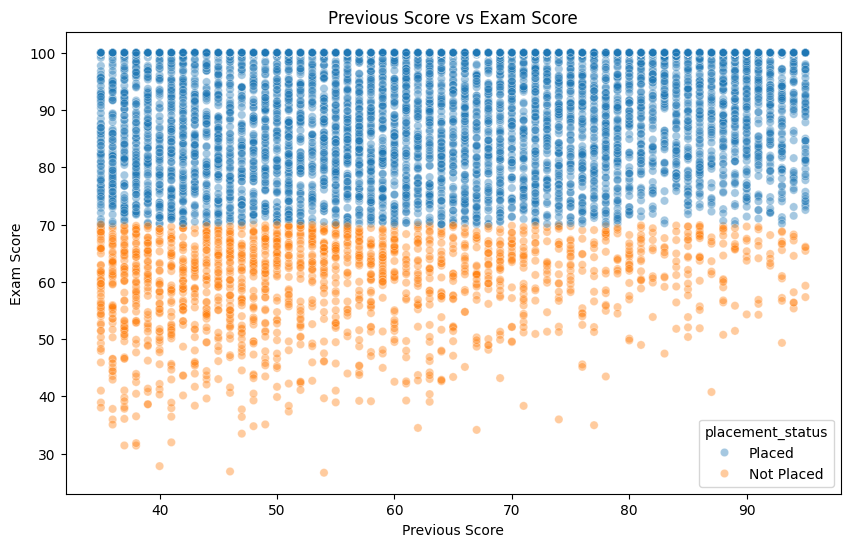

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='previous_score', y='exam_score', hue='placement_status', alpha=0.4)
plt.title('Previous Score vs Exam Score')
plt.xlabel('Previous Score')
plt.ylabel('Exam Score')
plt.show()

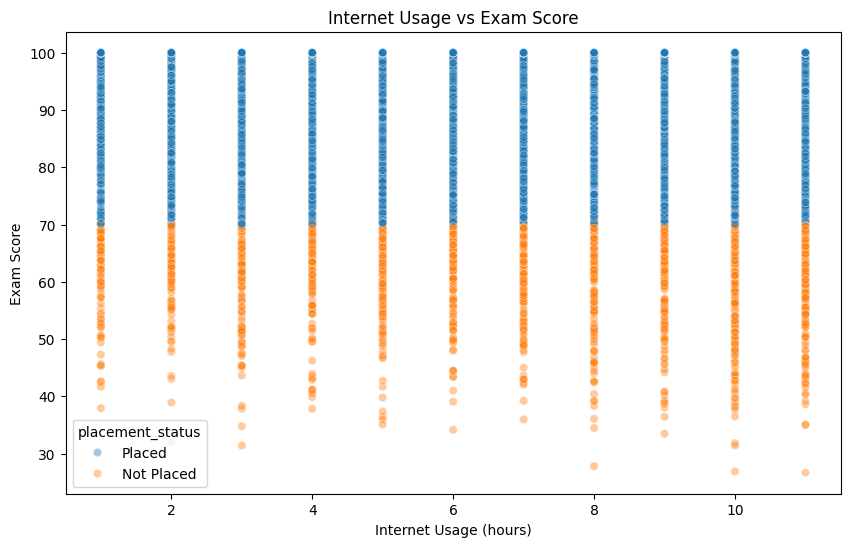

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='internet_usage', y='exam_score', hue='placement_status', alpha=0.4)
plt.title('Internet Usage vs Exam Score')
plt.xlabel('Internet Usage (hours)')
plt.ylabel('Exam Score')
plt.show()

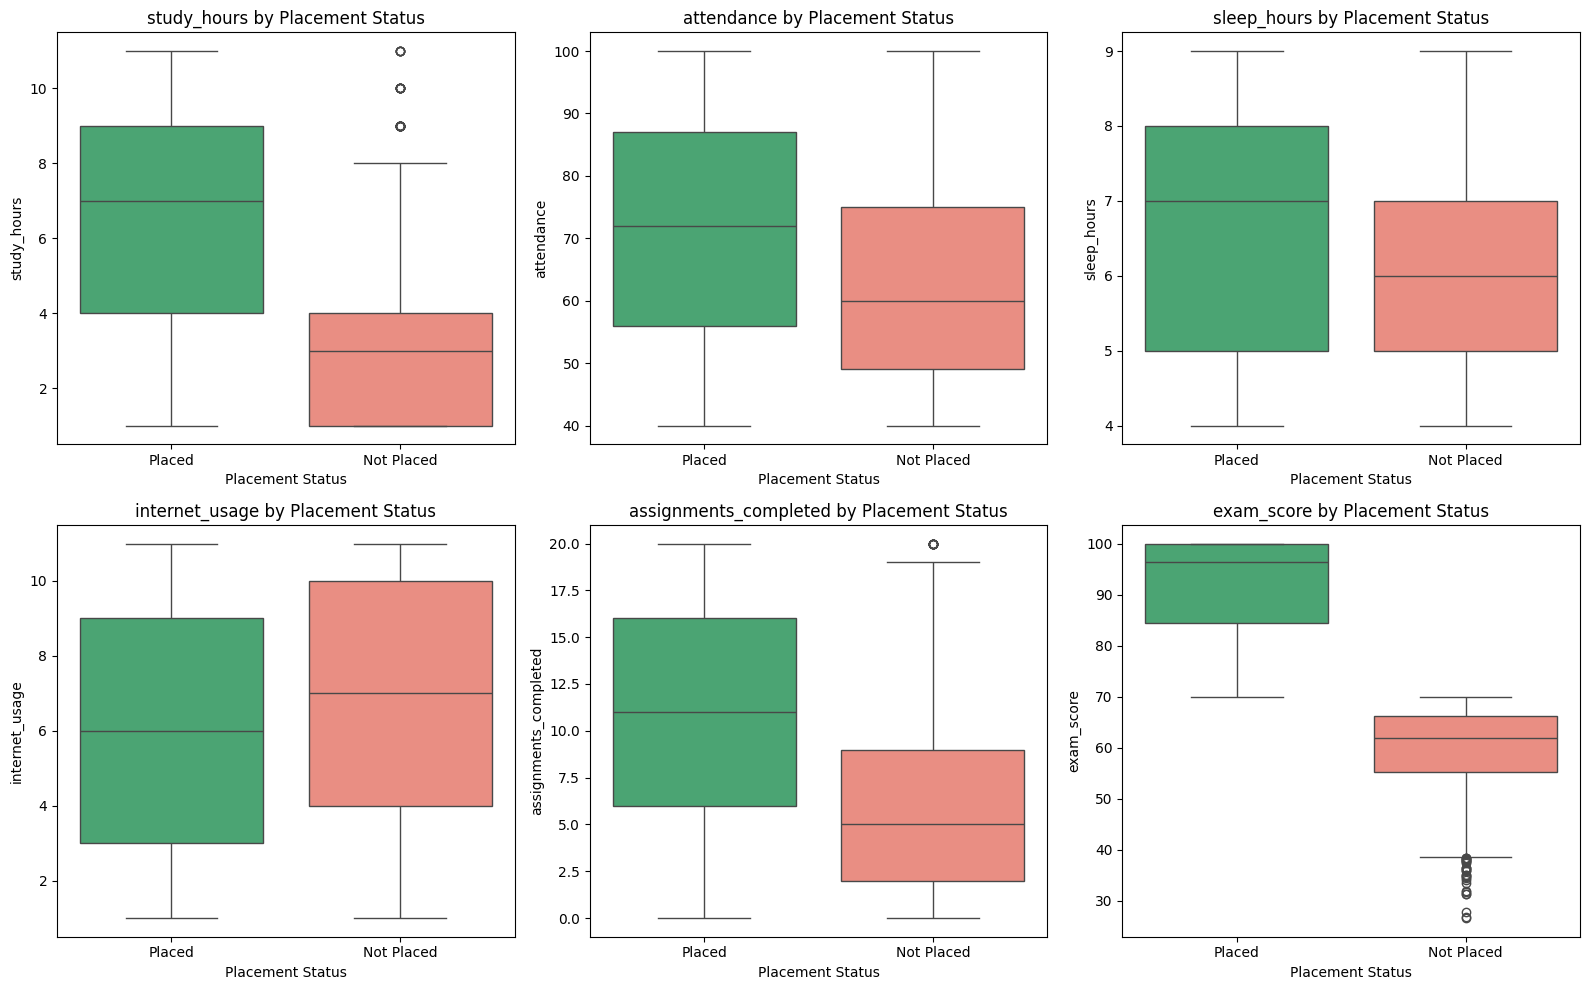

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))

numeric_features = ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'exam_score']

for ax, col in zip(axes.flatten(), numeric_features):
    sns.boxplot(data=df, x='placement_status', y=col, ax=ax, palette=['mediumseagreen', 'salmon'])
    ax.set_title(f'{col} by Placement Status')
    ax.set_xlabel('Placement Status')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

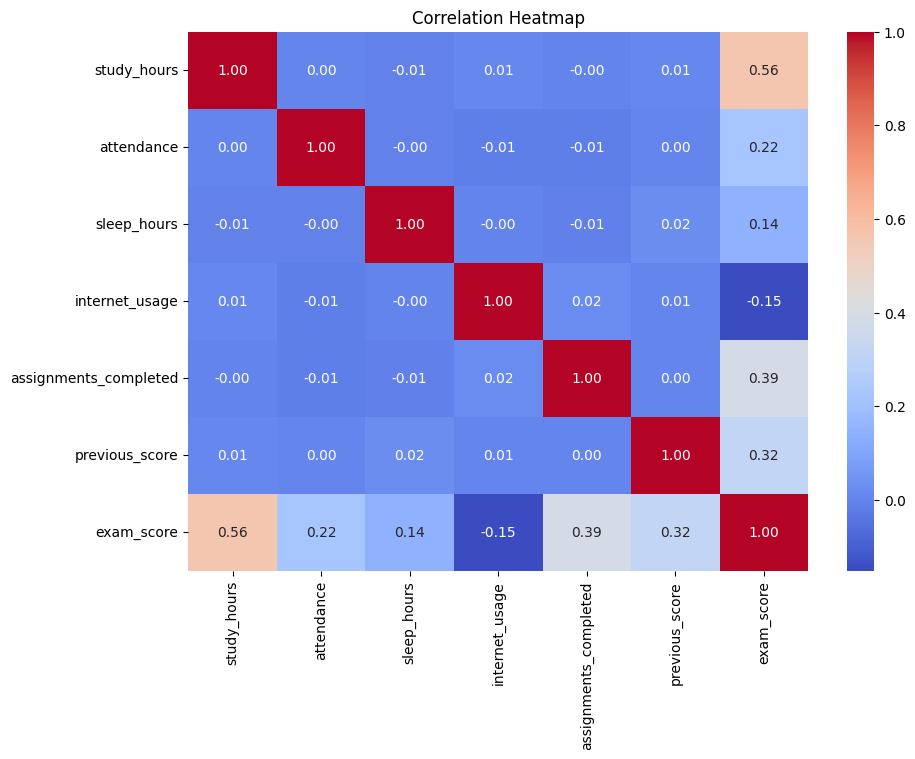

In [19]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

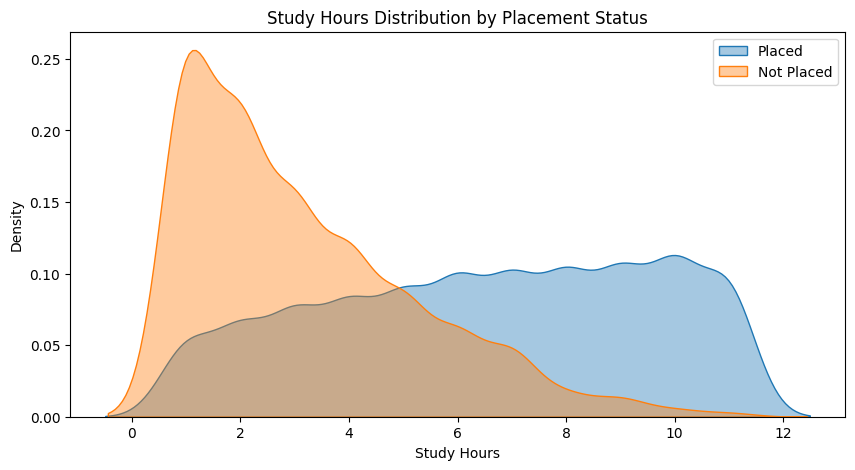

In [18]:
plt.figure(figsize=(10,5))
for status in df['placement_status'].unique():
    subset = df[df['placement_status'] == status]
    sns.kdeplot(subset['study_hours'], label=status, fill=True, alpha=0.4)

plt.title('Study Hours Distribution by Placement Status')
plt.xlabel('Study Hours')
plt.ylabel('Density')
plt.legend()
plt.show()

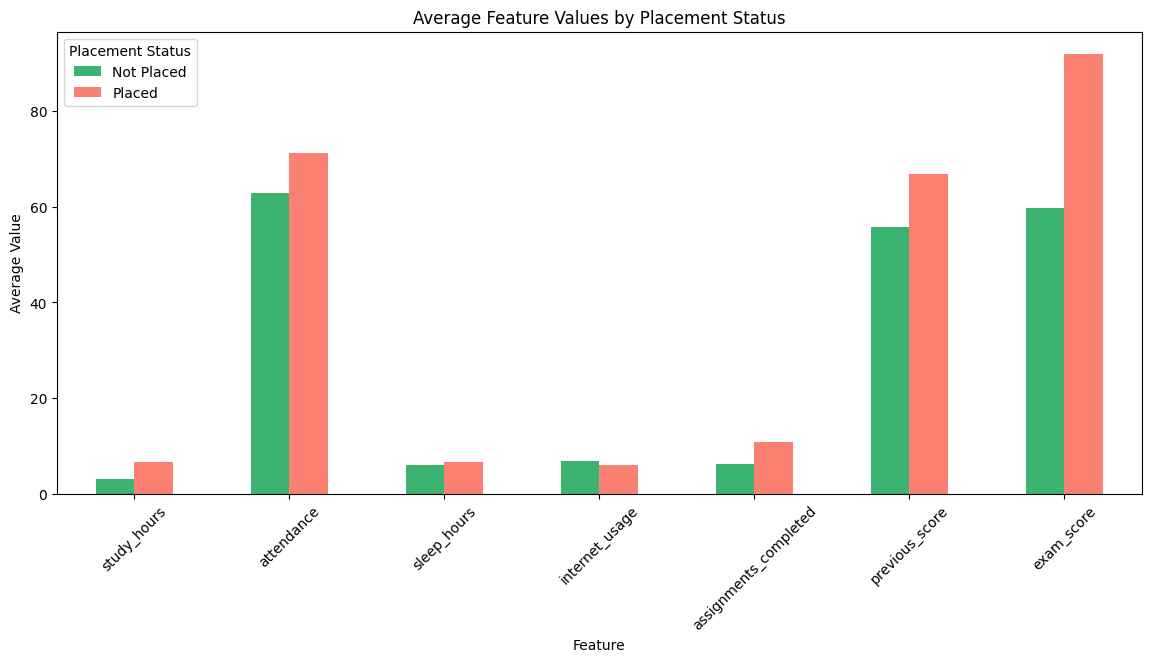

In [17]:
avg_by_placement = df.groupby('placement_status')[['study_hours','attendance','sleep_hours','internet_usage','assignments_completed','previous_score','exam_score']].mean()

avg_by_placement.T.plot(kind='bar', figsize=(14,6), color=['mediumseagreen', 'salmon'])
plt.title('Average Feature Values by Placement Status')
plt.xlabel('Feature')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(title='Placement Status')
plt.show()

In [16]:
sns.pairplot(df, hue='placement_status', palette=['mediumseagreen', 'salmon'], plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Student Features', y=1.02)
plt.show()

Output hidden; open in https://colab.research.google.com to view.